## Exercice n°1 (1/2 h)




Dans le modèle ci-dessous, pouvez-vous préciser :
- la taille du champ réceptif associé à un pixel d'une carte de caractéristique en sortie de enc3, par un calcul théorique.
- passer ce modèle sur un champ ne contenant que des zéros sauf pour une composante. En déduire la taille du champ réceptif empirique en sortie du modèle.


In [8]:
import torch
import torch.nn as nn

class MyNN(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, base=16):
        super().__init__()

        # 2 Conv2D
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_ch, base, kernel_size=3, stride=1, padding=1, bias=False),
            nn.ReLU(),
            nn.Conv2d(base, base, kernel_size=3, stride=1, padding=1, bias=False),
            nn.ReLU(),
        )

        # 2 Conv2D, first with stride=2
        self.enc2 = nn.Sequential(
            nn.Conv2d(base, base * 2, kernel_size=3, stride=2, padding=1, bias=False),
            nn.ReLU(),
            nn.Conv2d(base * 2, base * 2, kernel_size=3, stride=1, padding=1, bias=False),
            nn.ReLU(),
        )

        # again 2 Conv2D, first with stride=2
        self.enc3 = nn.Sequential(
            nn.Conv2d(base * 2, base * 4, kernel_size=3, stride=2, padding=1, bias=False),
            nn.ReLU(),
            nn.Conv2d(base * 4, base * 4, kernel_size=3, stride=1, padding=1, bias=False),
            nn.ReLU(),
        )

        # alternance Conv2D / ConvTranspose2D
        self.mid = nn.Conv2d(base * 4, base * 4, kernel_size=3, padding=1, bias=False)

        self.up1 = nn.ConvTranspose2d(base * 4, base * 2, kernel_size=2, stride=2, bias=False)
        self.dec1 = nn.Conv2d(base * 2, base * 2, kernel_size=3, padding=1, bias=False)

        self.up2 = nn.ConvTranspose2d(base * 2, base, kernel_size=2, stride=2, bias=False)
        self.dec2 = nn.Conv2d(base, base, kernel_size=3, padding=1, bias=False)

        self.head = nn.Conv2d(base, out_ch, kernel_size=1, bias=False)

    def forward(self, x):
        x = self.enc1(x)
        x = self.enc2(x)
        x = self.enc3(x)

        x = torch.relu(self.mid(x))

        x = self.up1(x)
        x = torch.relu(self.dec1(x))

        x = self.up2(x)
        x = torch.relu(self.dec2(x))

        return self.head(x)

## Réponse 1 : Calcul théorique du champ réceptif en sortie de enc3

Pour calculer le champ réceptif théorique, on suit la progression à travers les couches :

**Formule générale :** RF_new = RF_old + (kernel_size - 1) × stride_cumul_old

où stride_cumul est le produit de tous les strides jusqu'à cette couche.

**enc1 :**
- Conv2d(k=3, s=1, p=1) : RF = 1 + (3-1)×1 = **3**, stride_cumul = 1
- Conv2d(k=3, s=1, p=1) : RF = 3 + (3-1)×1 = **5**, stride_cumul = 1

**enc2 :**
- Conv2d(k=3, s=2, p=1) : RF = 5 + (3-1)×1 = **7**, stride_cumul = 2
- Conv2d(k=3, s=1, p=1) : RF = 7 + (3-1)×2 = **11**, stride_cumul = 2

**enc3 :**
- Conv2d(k=3, s=2, p=1) : RF = 11 + (3-1)×2 = **15**, stride_cumul = 4
- Conv2d(k=3, s=1, p=1) : RF = 15 + (3-1)×4 = **23**, stride_cumul = 4

**Réponse : Le champ réceptif théorique en sortie de enc3 est de 23×23 pixels.** 

Taille de l'image d'entrée: 64×64
Taille de la sortie: 64×64

Région non-nulle dans la sortie:
  Hauteur: 34 pixels (sortie)
  Largeur: 34 pixels (sortie)

Champ réceptif empirique (en pixels d'entrée):
  Hauteur: 34.0 pixels
  Largeur: 34.0 pixels
  Taille approximative: 34×34 pixels


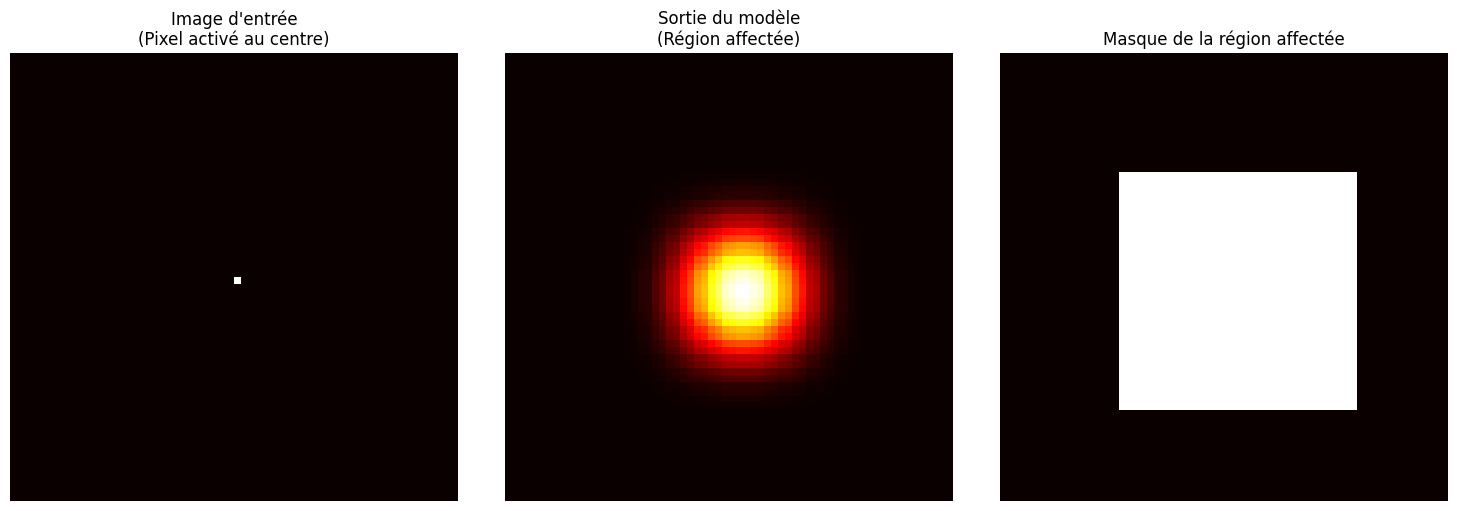

In [ ]:
# Réponse 2 : Test empirique du champ réceptif en sortie de enc3

import matplotlib.pyplot as plt
import numpy as np

# Créer le modèle
model = MyNN(in_ch=3, out_ch=1, base=16)
# Initialiser les poids à 1 pour faciliter le calcul
for m in model.modules():
    if hasattr(m, "weight") and m.weight is not None:
        m.weight.data.fill_(1.0)
    if hasattr(m, "bias") and m.bias is not None:
        m.bias.data.zero_()

model.eval()

# Créer une image d'entrée avec un seul pixel non-zéro
H, W = 128, 128  # Taille de l'image d'entrée

# Créer une image avec un seul pixel activé au centre
input_img = torch.zeros(1, 3, H, W)
input_img[0, 0, H//2, W//2] = 1.0  # Pixel central du premier canal

# Test 1 : Sortie de enc3 uniquement
with torch.no_grad():
    x = model.enc1(input_img)
    x = model.enc2(x)
    x_enc3 = model.enc3(x)  # Sortie de enc3

print("=== Test 1 : Champ réceptif en sortie de enc3 ===")
print(f"Taille de l'image d'entrée: {H}×{W}")
print(f"Taille de la sortie de enc3: {x_enc3.shape[2]}×{x_enc3.shape[3]}")

# Visualiser où la sortie est non-nulle (on prend le premier canal de features)
output_enc3_np = x_enc3[0, 0].numpy()
non_zero_enc3 = np.abs(output_enc3_np) > 1e-6

rows_enc3, cols_enc3 = np.where(non_zero_enc3)
if len(rows_enc3) > 0:
    min_row_enc3, max_row_enc3 = rows_enc3.min(), rows_enc3.max()
    min_col_enc3, max_col_enc3 = cols_enc3.min(), cols_enc3.max()
    
    output_h_enc3, output_w_enc3 = x_enc3.shape[2], x_enc3.shape[3]
    scale_h_enc3 = H / output_h_enc3
    scale_w_enc3 = W / output_w_enc3
    
    rf_h_enc3 = (max_row_enc3 - min_row_enc3 + 1) * scale_h_enc3
    rf_w_enc3 = (max_col_enc3 - min_col_enc3 + 1) * scale_w_enc3
    
    print(f"\nRégion non-nulle dans la sortie de enc3:")
    print(f"  Hauteur: {max_row_enc3 - min_row_enc3 + 1} pixels (sortie)")
    print(f"  Largeur: {max_col_enc3 - min_col_enc3 + 1} pixels (sortie)")
    print(f"\nFacteur d'échelle (entrée → sortie enc3): {scale_h_enc3:.1f}×{scale_w_enc3:.1f}")
    print(f"\nChamp réceptif empirique en sortie de enc3 (en pixels d'entrée):")
    print(f"  {rf_h_enc3:.1f}×{rf_w_enc3:.1f} pixels")
    print(f"\nComparaison avec le calcul théorique:")
    print(f"  Théorique: 23×23 pixels")
    print(f"  Empirique: {max(rf_h_enc3, rf_w_enc3):.0f}×{max(rf_h_enc3, rf_w_enc3):.0f} pixels")

# Test 2 : Sortie du modèle complet
with torch.no_grad():
    output = model(input_img)

print("\n=== Test 2 : Champ réceptif en sortie du modèle complet ===")
print(f"Taille de l'image d'entrée: {H}×{W}")
print(f"Taille de la sortie: {output.shape[2]}×{output.shape[3]}")

output_np = output[0, 0].numpy()
non_zero_mask = np.abs(output_np) > 1e-6

rows, cols = np.where(non_zero_mask)
if len(rows) > 0:
    min_row, max_row = rows.min(), rows.max()
    min_col, max_col = cols.min(), cols.max()
    
    # Pour la sortie finale, la taille est la même que l'entrée (pas de réduction)
    # Donc le champ réceptif empirique est directement la taille de la région non-nulle
    rf_height = max_row - min_row + 1
    rf_width = max_col - min_col + 1
    
    print(f"\nRégion non-nulle dans la sortie:")
    print(f"  Hauteur: {rf_height} pixels")
    print(f"  Largeur: {rf_width} pixels")
    print(f"\nChamp réceptif empirique (en pixels d'entrée):")
    print(f"  {rf_height}×{rf_width} pixels")
    print(f"\nComparaison avec le calcul théorique:")
    print(f"  Théorique: 37×37 pixels")
    print(f"  Empirique: {max(rf_height, rf_width)}×{max(rf_height, rf_width)} pixels")

# Visualisation
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Ligne 1 : Test enc3
axes[0, 0].imshow(input_img[0, 0].numpy(), cmap='hot')
axes[0, 0].set_title('Image d\'entrée\n(Pixel activé au centre)')
axes[0, 0].axis('off')

axes[0, 1].imshow(output_enc3_np, cmap='hot')
axes[0, 1].set_title(f'Sortie de enc3\n(RF empirique: {max(rf_h_enc3, rf_w_enc3):.0f}×{max(rf_h_enc3, rf_w_enc3):.0f}px)')
axes[0, 1].axis('off')

axes[0, 2].imshow(non_zero_enc3.astype(float), cmap='hot')
axes[0, 2].set_title('Masque enc3')
axes[0, 2].axis('off')

# Ligne 2 : Test modèle complet
axes[1, 0].imshow(input_img[0, 0].numpy(), cmap='hot')
axes[1, 0].set_title('Image d\'entrée')
axes[1, 0].axis('off')

axes[1, 1].imshow(output_np, cmap='hot')
axes[1, 1].set_title(f'Sortie finale\n(RF empirique: {max(rf_height, rf_width)}×{max(rf_height, rf_width)}px)')
axes[1, 1].axis('off')

axes[1, 2].imshow(non_zero_mask.astype(float), cmap='hot')
axes[1, 2].set_title('Masque sortie finale')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()